In [ ]:
import sys
import pandapower as pp
import pandapower.networks as nw
import pandas as pd
import nbformat
import matplotlib.pyplot as plt
from pandapower.plotting.plotly import simple_plotly
from pandapower.plotting.plotly import pf_res_plotly
import copy
import pandapower as pp
from pandapower.plotting.plotly import simple_plotly
from pandapower.plotting.plotly import pf_res_plotly


net = pp.networks.create_cigre_network_mv(with_der=False)


net.load['p_mw']= net.load['p_mw'] / 2
net.load['q_mvar']= net.load['q_mvar'] / 2

pp.runpp(net)
# print(net.load)

numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


         name  bus      p_mw    q_mvar  const_z_percent  const_i_percent  \
0     Load R1    1  7.497000  1.522331              0.0              0.0   
1     Load R3    3  0.138225  0.034642              0.0              0.0   
2     Load R4    4  0.215825  0.054091              0.0              0.0   
3     Load R5    5  0.363750  0.091164              0.0              0.0   
4     Load R6    6  0.274025  0.068677              0.0              0.0   
5     Load R8    8  0.293425  0.073539              0.0              0.0   
6    Load R10   10  0.237650  0.059561              0.0              0.0   
7    Load R11   11  0.164900  0.041328              0.0              0.0   
8    Load R12   12  7.497000  1.522331              0.0              0.0   
9    Load R14   14  0.104275  0.026134              0.0              0.0   
10   Load CI1    1  2.422500  0.796237              0.0              0.0   
11   Load CI3    3  0.112625  0.069799              0.0              0.0   
12   Load CI

# Step 3


First Justify here the choice of vehicle for each Shop:
(We can choose whatever we want for justification but it needs to be based on something=> Data or assumption)

Mathem:
To do

Postnord:
To do


ICA:

to do

Airmee: 

to do

What to do in Step 3: 
We have the Data from Efleet scheduler: 

Import those Data: Time where the trucks are charging / Energy consumption during the Day

We need to calculate how much we need to charge during the night.

We assume that people can switch the plugs from a car to another at any time.

First Step is NOT Optimizing the Charging (Dumb charging)

Create a dictionary with Different Type of charger and Power rates that we can switch to compare the charging efficiency later : https://alternative-fuels-observatory.ec.europa.eu/general-information/recharging-systems

=> Justify the best choices

Add the car load to the actual power curve


Processing schedule_Airmee ...
  Tested 1 chargers -> success=False, unmet=124.130 kWh
  Tested 2 chargers -> success=True, unmet=0.000 kWh
  -> Minimum chargers required: 2


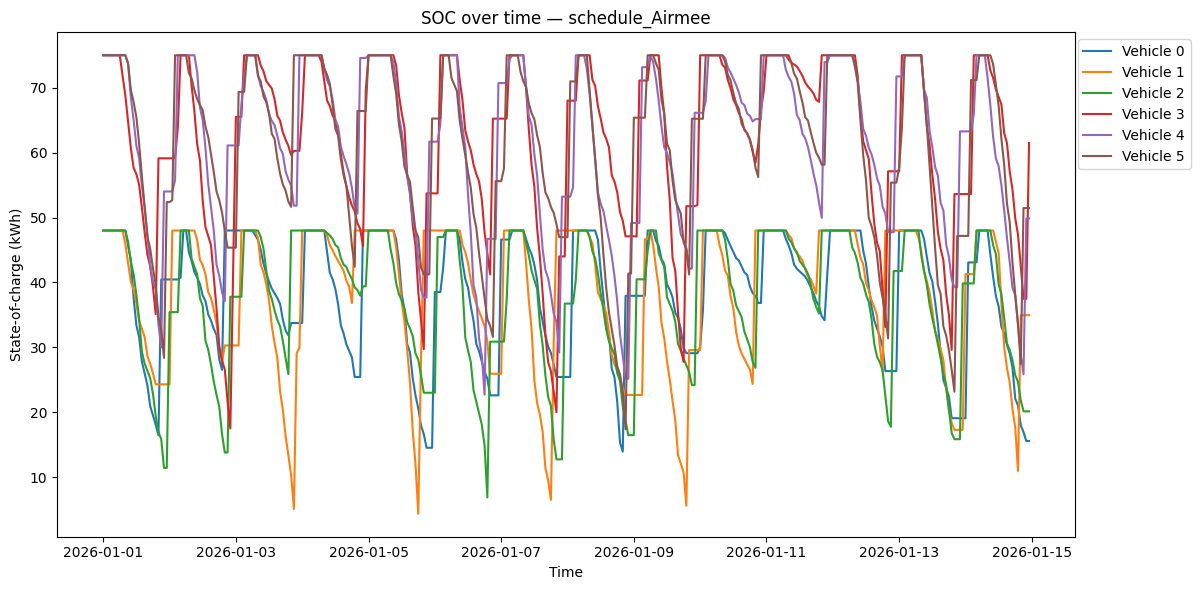

Processing schedule_Postnord ...
  Tested 1 chargers -> success=False, unmet=3335.822 kWh
  Tested 2 chargers -> success=False, unmet=1138.848 kWh
  Tested 3 chargers -> success=False, unmet=67.856 kWh
  Tested 4 chargers -> success=True, unmet=0.000 kWh
  -> Minimum chargers required: 4


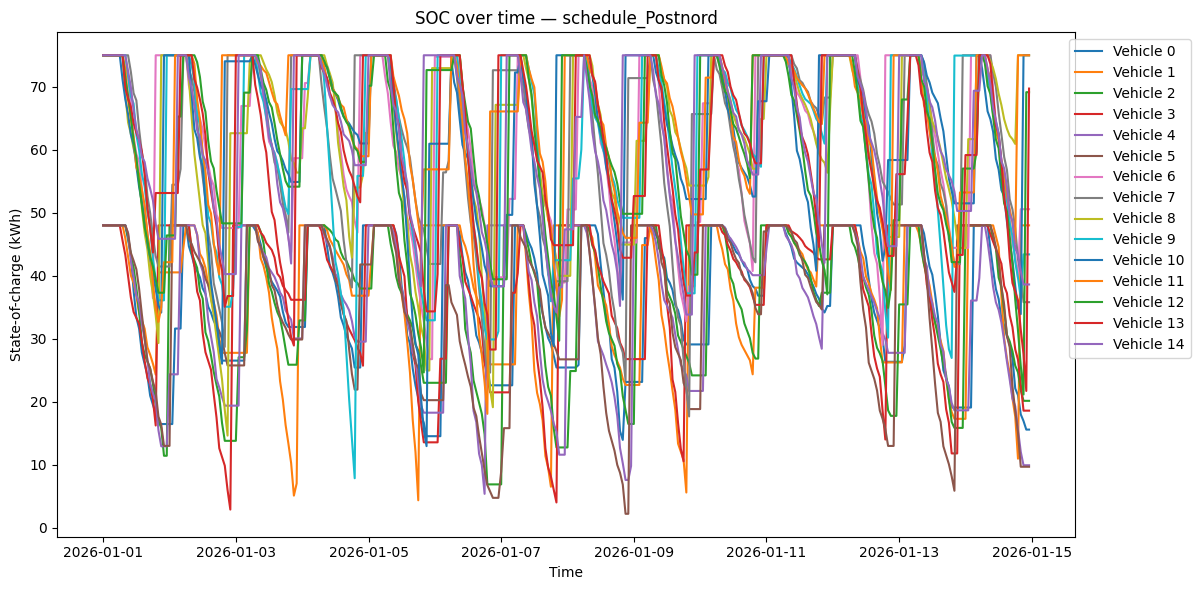

Processing schedule_Mathem ...
  Tested 1 chargers -> success=False, unmet=474.509 kWh
  Tested 2 chargers -> success=True, unmet=0.000 kWh
  -> Minimum chargers required: 2


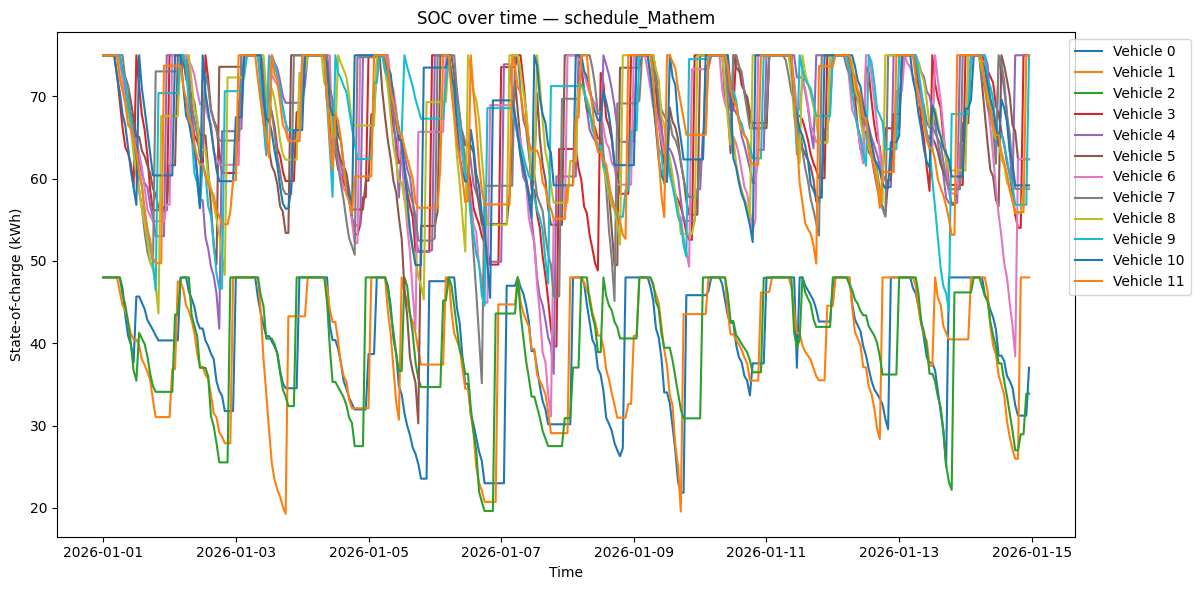

Processing schedule_ICA ...
  Tested 1 chargers -> success=True, unmet=0.000 kWh
  -> Minimum chargers required: 1


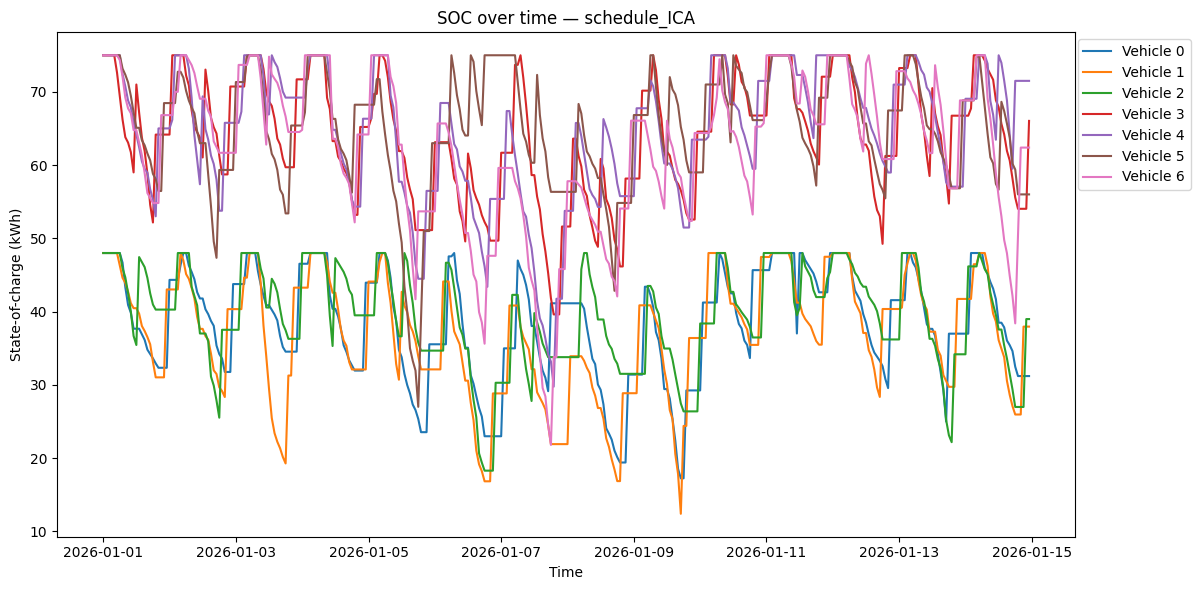


Summary:
 schedule_Airmee: 2  (ok)
 schedule_Postnord: 4  (ok)
 schedule_Mathem: 2  (ok)
 schedule_ICA: 1  (ok)


In [20]:
import pandas as pd
from pathlib import Path
import os
import math
import matplotlib.pyplot as plt

# -------------------------
# Config / assumptions
# -------------------------
notebook_dir = Path(os.getcwd())
base_path = notebook_dir.parent / "data" / "Output"

# Vehicle inlet rates (kW) and battery capacities (kWh)
vehicle_charging_limits = {"Renault": 80.0, "Toyota": 100.0}
battery_capacities = {"Renault": 48.0, "Toyota": 75.0}

# Use Fast AC only: charger assumed capacity (kW). Change if your charger physical rating differs.
FAST_AC_CAPACITY_KW = 12

# Shops (folders contain shop.csv). Adjust names if necessary.
shops = ["schedule_Airmee", "schedule_Postnord", "schedule_Mathem", "schedule_ICA"]

# Maximum number of chargers to test (safety cap). Usually you won't need more chargers than vehicles.
MAX_CHARGERS_TO_TEST = 20

# -------------------------
# Helper: simulate week with m chargers for one shop
# -------------------------
def simulate_shop(file_path, m_chargers, debug=False):
    df = pd.read_csv(file_path)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)

    timestamps = sorted(df['date'].unique())
    vehicles = sorted(df['VehicleID'].unique())

    # Vehicle type mapping
    vehicle_types = df.groupby('VehicleID')['VehicleType'].first().to_dict()

    # Precompute inlet per vehicle
    inlet = {vid: vehicle_charging_limits.get(vehicle_types.get(vid), FAST_AC_CAPACITY_KW) for vid in vehicles}

    # --- FIX: dummy depot night before week starts ---
    # Start every vehicle with its full battery
    SOC = {}
    for vid in vehicles:
        vtype = vehicle_types.get(vid, None)
        cap = battery_capacities.get(vtype, 48.0)  # fallback = 48
        SOC[vid] = cap

    # Traces
    soc_trace = {vid: [] for vid in vehicles}
    time_trace = []

    unmet_energy_total = 0.0

    # --- main simulation loop ---
    for ts in timestamps:
        df_h = df[df['date'] == ts]

        # Apply driving consumption
        for _, row in df_h.iterrows():
            vid = row['VehicleID']
            cons = float(row.get('Consumption_kWh', 0.0))
            prev_soc = SOC.get(vid, 0.0)
            new_soc = prev_soc - cons
            if new_soc < -1e-9:
                unmet = -new_soc
                unmet_energy_total += unmet
                SOC[vid] = 0.0
            else:
                SOC[vid] = new_soc

        # Charging when at depot
        depot_rows = df_h[df_h['Location'] == 1]
        present_vids = depot_rows['VehicleID'].unique().tolist()
        available_energy = m_chargers * FAST_AC_CAPACITY_KW  # 1h window

        needs = []
        for vid in present_vids:
            vtype = vehicle_types.get(vid)
            cap = battery_capacities.get(vtype, 48.0)
            need = max(0.0, cap - SOC.get(vid, 0.0))
            max_accept = inlet.get(vid, FAST_AC_CAPACITY_KW)
            if need > 1e-9:
                needs.append({'vid': vid, 'need': need, 'max_accept': max_accept})

        needs.sort(key=lambda x: x['need'], reverse=True)
        for n in needs:
            if available_energy <= 1e-9:
                break
            take = min(n['need'], n['max_accept'], available_energy)
            SOC[n['vid']] += take
            available_energy -= take

        for vid in vehicles:
            soc_trace[vid].append(SOC.get(vid, 0.0))
        time_trace.append(ts)

    success = (unmet_energy_total <= 1e-6)
    trace = {"time": time_trace, "soc_trace": soc_trace, "unmet_energy_total": unmet_energy_total}
    return success, trace


# -------------------------
# Find minimal chargers per shop using incremental search
# -------------------------
def find_min_chargers_for_shop(file_path, max_chargers=MAX_CHARGERS_TO_TEST, debug=False):
    # Try m = 1..max_chargers
    for m in range(1, max_chargers + 1):
        success, trace = simulate_shop(file_path, m, debug=debug)
        print(f"  Tested {m} chargers -> success={success}, unmet={trace['unmet_energy_total']:.3f} kWh")
        if debug:
            print(f"Tested {m} chargers -> success={success}, unmet={trace['unmet_energy_total']:.3f} kWh")
        if success:
            return m, trace
    # if we reach here, not feasible with tested chargers
    return None, None

# -------------------------
# Plotting: SOC time series per vehicle
# -------------------------
def plot_soc(trace, file_path, shop_name, save_fig=False):
    time = trace['time']
    soc = trace['soc_trace']

    plt.figure(figsize=(12, 6))
    for vid, series in soc.items():
        plt.plot(time, series, label=f"Vehicle {vid}")
    plt.xlabel("Time")
    plt.ylabel("State-of-charge (kWh)")
    plt.title(f"SOC over time — {shop_name}")
    plt.legend(loc='upper right', bbox_to_anchor=(1.12, 1.0))
    plt.tight_layout()
    if save_fig:
        out = Path(file_path).with_suffix('.png')
        plt.savefig(out, dpi=150)
        print("Saved figure to", out)
    plt.show()

# -------------------------
# Run for all shops
# -------------------------
if __name__ == "__main__":
    results = {}
    for shop in shops:
        shop_folder = base_path / shop
        file = shop_folder / f"{shop}.csv"
        if not file.exists():
            print(f"[WARN] file not found: {file}")
            results[shop] = {'min_chargers': None, 'reason': 'file_missing'}
            continue

        print(f"Processing {shop} ...")
        min_ch, trace = find_min_chargers_for_shop(file, max_chargers=MAX_CHARGERS_TO_TEST, debug=False)

        if min_ch is None:
            print(f"  -> Not feasible with up to {MAX_CHARGERS_TO_TEST} chargers.")
            results[shop] = {'min_chargers': None, 'reason': 'not_feasible'}
        else:
            print(f"  -> Minimum chargers required: {min_ch}")
            results[shop] = {'min_chargers': min_ch, 'trace': trace}
            # plot SOC trace (you can set save_fig=True to write png)
            plot_soc(trace, file, shop, save_fig=False)

    print("\nSummary:")
    for shop, info in results.items():
        print(f" {shop}: {info.get('min_chargers')}  ({info.get('reason','ok')})")


Debugging For Postnord Issue 


DETAILED ANALYSIS FOR schedule_Postnord

✓ No energy shortages detected!

RUNNING FULL ANALYSIS FOR ALL SHOPS

Processing schedule_Airmee ...
  Tested 1 chargers -> success=False, unmet=124.130 kWh
  Tested 2 chargers -> success=True, unmet=0.000 kWh
  -> Minimum chargers required: 2


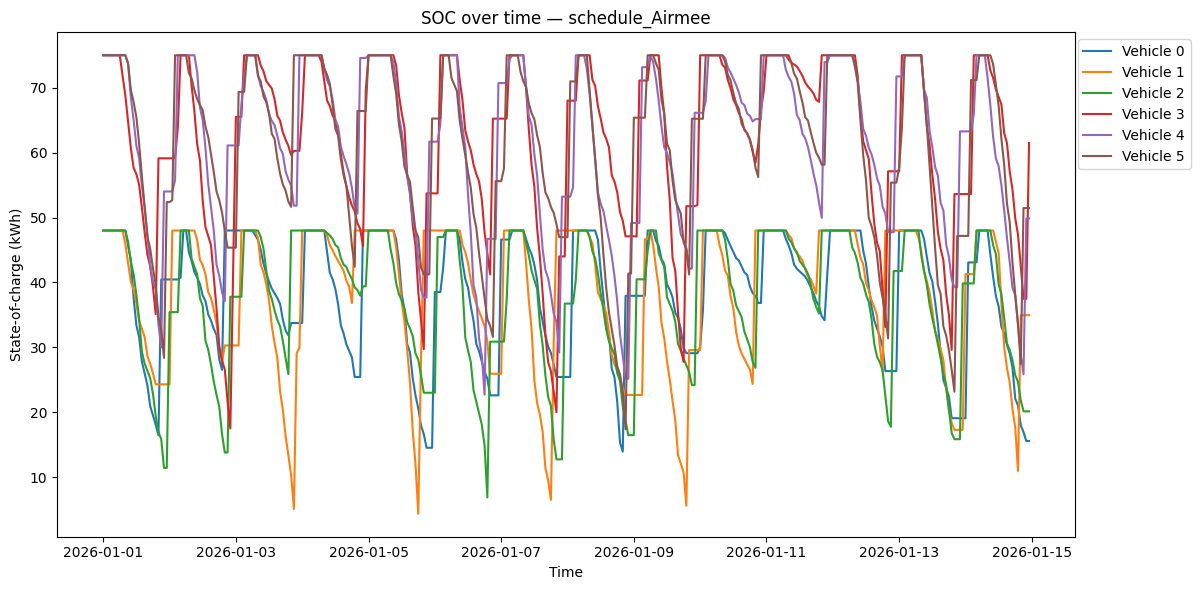

Processing schedule_Postnord ...
  Tested 1 chargers -> success=False, unmet=3335.822 kWh
  Tested 2 chargers -> success=False, unmet=1138.848 kWh
  Tested 3 chargers -> success=False, unmet=67.856 kWh
  Tested 4 chargers -> success=True, unmet=0.000 kWh
  -> Minimum chargers required: 4


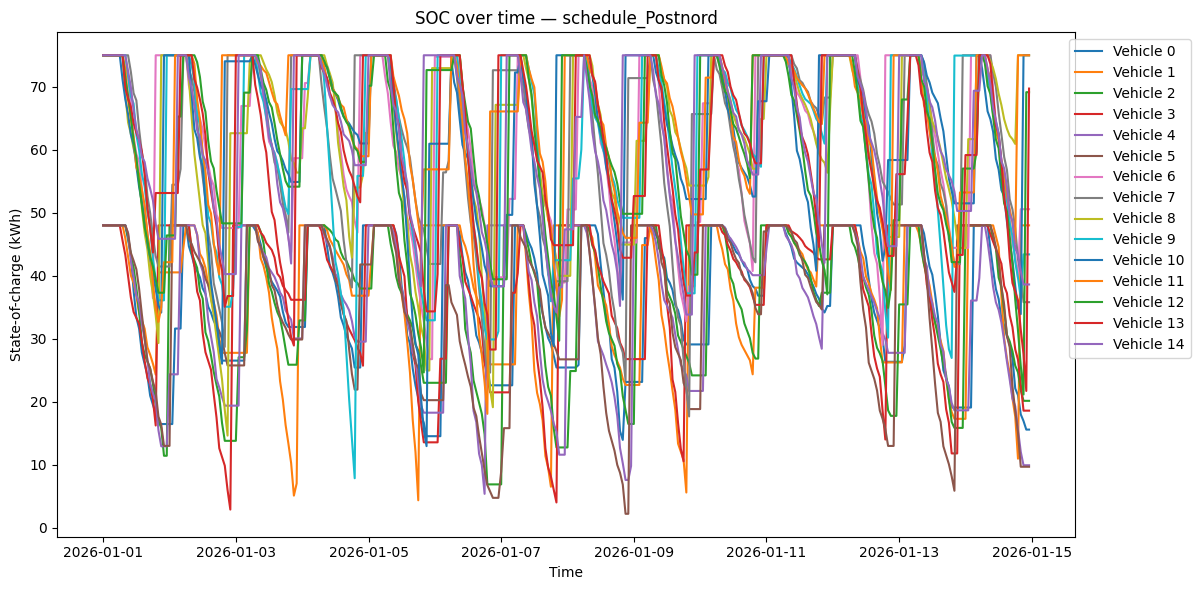

Processing schedule_Mathem ...
  Tested 1 chargers -> success=False, unmet=474.509 kWh
  Tested 2 chargers -> success=True, unmet=0.000 kWh
  -> Minimum chargers required: 2


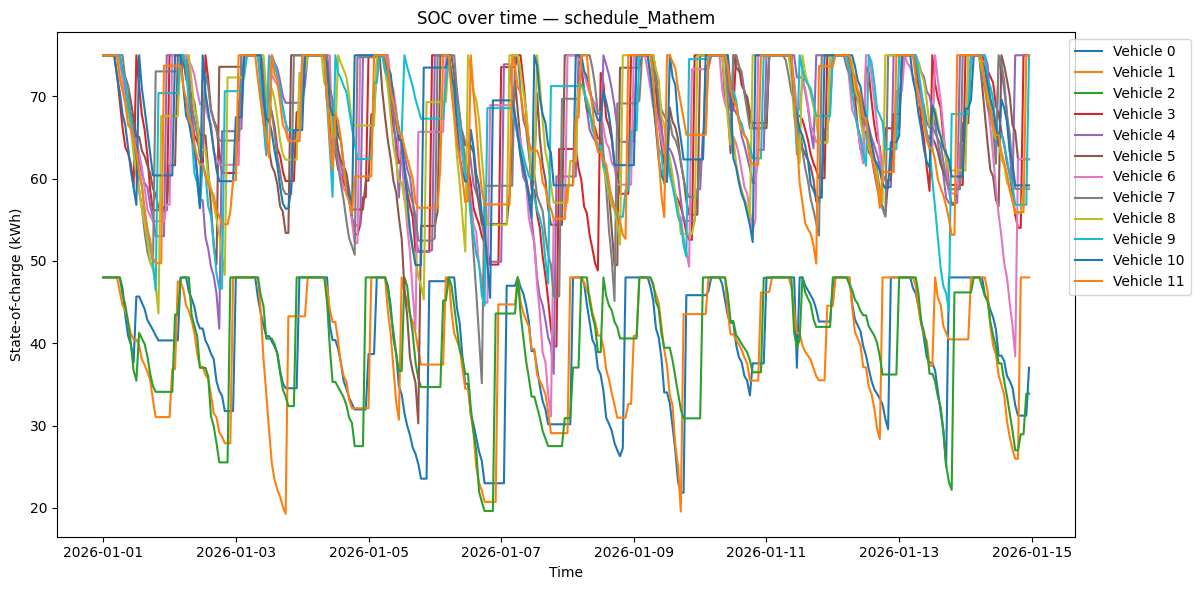

Processing schedule_ICA ...
  Tested 1 chargers -> success=True, unmet=0.000 kWh
  -> Minimum chargers required: 1


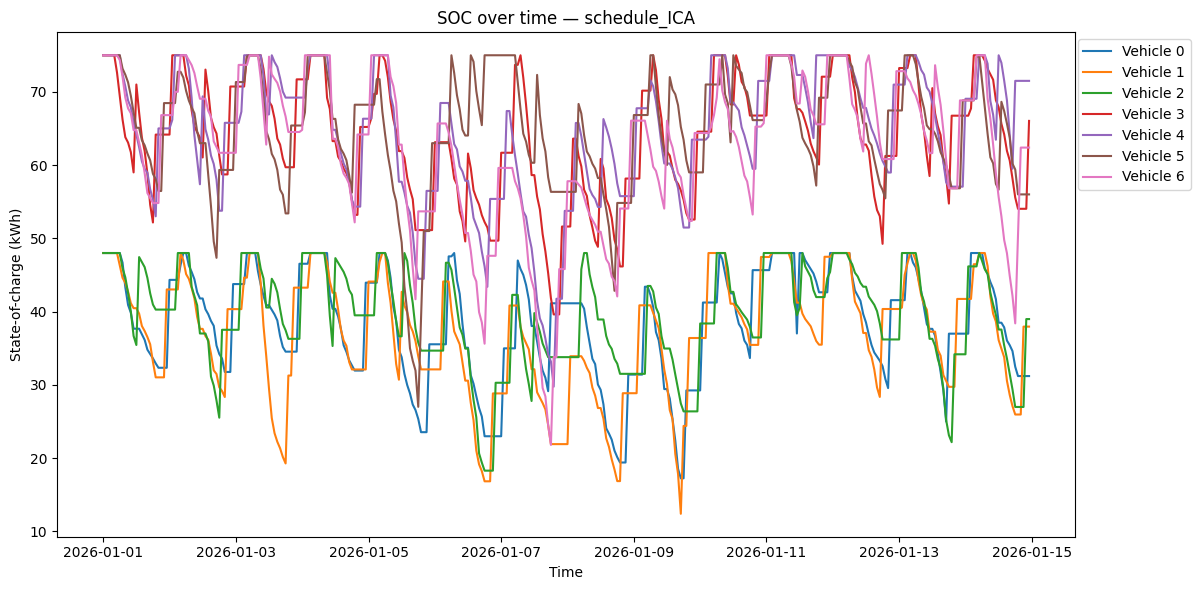


Summary:
 schedule_Airmee: 2  (ok)
 schedule_Postnord: 4  (ok)
 schedule_Mathem: 2  (ok)
 schedule_ICA: 1  (ok)


In [21]:
import pandas as pd
from pathlib import Path
import os
import math
import matplotlib.pyplot as plt

# -------------------------
# Config / assumptions
# -------------------------
notebook_dir = Path(os.getcwd())
base_path = notebook_dir.parent / "data" / "Output"

vehicle_charging_limits = {"Renault": 80.0, "Toyota": 100.0}
battery_capacities = {"Renault": 48.0, "Toyota": 75.0}

FAST_AC_CAPACITY_KW = 12

shops = ["schedule_Airmee", "schedule_Postnord", "schedule_Mathem", "schedule_ICA"]

MAX_CHARGERS_TO_TEST = 20

# -------------------------
# Enhanced simulation with detailed debugging
# -------------------------
def simulate_shop(file_path, m_chargers, debug=False):
    df = pd.read_csv(file_path)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)

    timestamps = sorted(df['date'].unique())
    vehicles = sorted(df['VehicleID'].unique())

    vehicle_types = df.groupby('VehicleID')['VehicleType'].first().to_dict()
    inlet = {vid: vehicle_charging_limits.get(vehicle_types.get(vid), FAST_AC_CAPACITY_KW) for vid in vehicles}

    # Initialize all vehicles with full battery
    SOC = {}
    for vid in vehicles:
        vtype = vehicle_types.get(vid, None)
        cap = battery_capacities.get(vtype, 48.0)
        SOC[vid] = cap

    soc_trace = {vid: [] for vid in vehicles}
    time_trace = []
    unmet_energy_total = 0.0
    unmet_events = []  # Track where shortages occur

    for ts in timestamps:
        df_h = df[df['date'] == ts]

        # Apply driving consumption
        for _, row in df_h.iterrows():
            vid = row['VehicleID']
            cons = float(row.get('Consumption_kWh', 0.0))
            location = row.get('Location', -1)
            prev_soc = SOC.get(vid, 0.0)
            new_soc = prev_soc - cons
            
            if new_soc < -1e-9:
                unmet = -new_soc
                unmet_energy_total += unmet
                unmet_events.append({
                    'timestamp': ts,
                    'vehicle': vid,
                    'prev_soc': prev_soc,
                    'consumption': cons,
                    'shortage': unmet,
                    'location': location,
                    'vehicle_type': vehicle_types.get(vid)
                })
                if debug:
                    print(f"  SHORTAGE at {ts}: Vehicle {vid} needs {cons:.2f} kWh but only has {prev_soc:.2f} kWh (shortage: {unmet:.2f} kWh)")
                SOC[vid] = 0.0
            else:
                SOC[vid] = new_soc

        # Charging when at depot
        depot_rows = df_h[df_h['Location'] == 1]
        present_vids = depot_rows['VehicleID'].unique().tolist()
        available_energy = m_chargers * FAST_AC_CAPACITY_KW

        needs = []
        for vid in present_vids:
            vtype = vehicle_types.get(vid)
            cap = battery_capacities.get(vtype, 48.0)
            need = max(0.0, cap - SOC.get(vid, 0.0))
            max_accept = inlet.get(vid, FAST_AC_CAPACITY_KW)
            if need > 1e-9:
                needs.append({'vid': vid, 'need': need, 'max_accept': max_accept})

        needs.sort(key=lambda x: x['need'], reverse=True)
        for n in needs:
            if available_energy <= 1e-9:
                break
            take = min(n['need'], n['max_accept'], available_energy)
            SOC[n['vid']] += take
            available_energy -= take

        for vid in vehicles:
            soc_trace[vid].append(SOC.get(vid, 0.0))
        time_trace.append(ts)

    success = (unmet_energy_total <= 1e-6)
    trace = {
        "time": time_trace, 
        "soc_trace": soc_trace, 
        "unmet_energy_total": unmet_energy_total,
        "unmet_events": unmet_events
    }
    return success, trace


# -------------------------
# Analyze first shortage in detail
# -------------------------
def analyze_first_shortage(file_path, m_chargers=4):
    """Run simulation and report details of first energy shortage"""
    print(f"\n{'='*70}")
    print(f"DETAILED ANALYSIS FOR {Path(file_path).parent.name}")
    print(f"{'='*70}")
    
    success, trace = simulate_shop(file_path, m_chargers, debug=True)
    
    if trace['unmet_events']:
        print(f"\n Found {len(trace['unmet_events'])} shortage event(s)")
        print(f" Total unmet energy: {trace['unmet_energy_total']:.3f} kWh\n")
        
        for i, event in enumerate(trace['unmet_events'], 1):
            print(f"Shortage Event #{i}:")
            print(f"  Time: {event['timestamp']}")
            print(f"  Vehicle: {event['vehicle']} ({event['vehicle_type']})")
            print(f"  Location: {'Depot' if event['location'] == 1 else 'Away from depot'}")
            print(f"  Previous SOC: {event['prev_soc']:.2f} kWh")
            print(f"  Consumption needed: {event['consumption']:.2f} kWh")
            print(f"  Energy shortage: {event['shortage']:.2f} kWh")
            print()
            
            # Check what happened in previous hours
            df = pd.read_csv(file_path)
            df['date'] = pd.to_datetime(df['date'])
            vid = event['vehicle']
            
            # Get history for this vehicle
            vehicle_history = df[df['VehicleID'] == vid].sort_values('date')
            event_idx = vehicle_history[vehicle_history['date'] == event['timestamp']].index
            
            if len(event_idx) > 0:
                print(f"  Recent history for Vehicle {vid}:")
                start_idx = max(0, event_idx[0] - 5)
                end_idx = min(len(vehicle_history), event_idx[0] + 2)
                history_slice = vehicle_history.iloc[start_idx:end_idx]
                
                for _, row in history_slice.iterrows():
                    loc_str = "DEPOT" if row['Location'] == 1 else "AWAY"
                    marker = " <<< SHORTAGE HERE" if row['date'] == event['timestamp'] else ""
                    print(f"    {row['date']} | {loc_str} | Consumption: {row.get('Consumption_kWh', 0):.2f} kWh{marker}")
    else:
        print("\n✓ No energy shortages detected!")
    
    return trace


# -------------------------
# Find minimal chargers (same as before)
# -------------------------
def find_min_chargers_for_shop(file_path, max_chargers=MAX_CHARGERS_TO_TEST, debug=False):
    for m in range(1, max_chargers + 1):
        success, trace = simulate_shop(file_path, m, debug=debug)
        print(f"  Tested {m} chargers -> success={success}, unmet={trace['unmet_energy_total']:.3f} kWh")
        if success:
            return m, trace
    return None, None


# -------------------------
# Plotting function
# -------------------------
def plot_soc(trace, file_path, shop_name, save_fig=False):
    time = trace['time']
    soc = trace['soc_trace']

    plt.figure(figsize=(12, 6))
    for vid, series in soc.items():
        plt.plot(time, series, label=f"Vehicle {vid}")
    plt.xlabel("Time")
    plt.ylabel("State-of-charge (kWh)")
    plt.title(f"SOC over time — {shop_name}")
    plt.legend(loc='upper right', bbox_to_anchor=(1.12, 1.0))
    plt.tight_layout()
    if save_fig:
        out = Path(file_path).with_suffix('.png')
        plt.savefig(out, dpi=150)
        print("Saved figure to", out)
    plt.show()


# -------------------------
# Main execution
# -------------------------
if __name__ == "__main__":
    # First, run detailed analysis on Postnord
    postnord_file = base_path / "schedule_Postnord" / "schedule_Postnord.csv"
    if postnord_file.exists():
        analyze_first_shortage(postnord_file, m_chargers=4)
    
    print("\n" + "="*70)
    print("RUNNING FULL ANALYSIS FOR ALL SHOPS")
    print("="*70 + "\n")
    
    results = {}
    for shop in shops:
        shop_folder = base_path / shop
        file = shop_folder / f"{shop}.csv"
        if not file.exists():
            print(f"[WARN] file not found: {file}")
            results[shop] = {'min_chargers': None, 'reason': 'file_missing'}
            continue

        print(f"Processing {shop} ...")
        min_ch, trace = find_min_chargers_for_shop(file, max_chargers=MAX_CHARGERS_TO_TEST, debug=False)

        if min_ch is None:
            print(f"  -> Not feasible with up to {MAX_CHARGERS_TO_TEST} chargers.")
            results[shop] = {'min_chargers': None, 'reason': 'not_feasible'}
        else:
            print(f"  -> Minimum chargers required: {min_ch}")
            results[shop] = {'min_chargers': min_ch, 'trace': trace}
            plot_soc(trace, file, shop, save_fig=False)

    print("\nSummary:")
    for shop, info in results.items():
        print(f" {shop}: {info.get('min_chargers')}  ({info.get('reason','ok')})")

Step 5 Instructions: to minimise the losses we need to have all the lines have the least Current possible (more balanced network)=> Minimise the Current on all the lines. We need to change the scheduler of the charging for this.  (Pandapower has a loss value )=> can also be used 